In [14]:
import os
import time
import umap
import yaml
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import datetime as datetime
import matplotlib.pyplot as plt 
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset, default_collate
from mm_cgmvae import *
from train_mmvae import*
from VAE_model_architectures import*

In [13]:
params = {
    'general': {
'dataset': 'DO',  # AD
'model_type': 'CGMVAE', # VAE or CVAE or GMVAE 
'random_seed': 10, # 85 # 123 for same region, seed 22 for multi-region no offset, 22 for multi-region offset
'learn_prior': False,
'accelerator': True,
'M': 2,
'epochs': 10,
'num_iwae_samples': 1, 
'learning_rate': 1e-3, 
'offset_centers': False
    }
}
dataset = params['general']['dataset']
model_type = params['general']['model_type']
random_seed = params['general']['random_seed']
learn_prior = params['general']['learn_prior']
accelerator = params['general']['accelerator']
M = params['general']['M']
epochs = params['general']['epochs']
num_iwae_samples = params['general']['num_iwae_samples']
learning_rate = params['general']['learning_rate']
offset_centers = params['general']['offset_centers']

In [9]:
dataset_params = {
'input_dim': [5873, 36],
'H1': [128, 35], 
'H2': [64, 16], 
'H3': [32, 10],
'latent_dim': 10,
'batch_size': 271, # divided by length, 9751 / 971 leaves last batch = 271
'scales': [1, 1],
'dataset_abbrev': ['Geno', 'Physio'],
'output_folder': '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/vanillavae4_genoreweighted_test',
'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_cfc.csv',
#'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio.csv',
'gmm_centers_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv',
'gmm_std': 2,
'num_classes': 4,
'num_kl_samples': 100,
'train_osd': False, 
'outcome': 'cfm'
}
params['dataset_params'] = dataset_params
input_dim = params['dataset_params']['input_dim']
H1 = params['dataset_params']['H1']
H2 = params['dataset_params']['H2']
H3 = params['dataset_params']['H3']
latent_dim = params['dataset_params']['latent_dim']
batch_size = params['dataset_params']['batch_size']
scales = params['dataset_params']['scales']
dataset_abbrev = params['dataset_params']['dataset_abbrev']
output_folder = params['dataset_params']['output_folder']
input_path = params['dataset_params']['input_path']
gmm_centers_path = params['dataset_params']['gmm_centers_path']
gmm_std = params['dataset_params']['gmm_std']
num_classes = params['dataset_params']['num_classes']
num_kl_samples = params['dataset_params']['num_kl_samples']
train_osd = params['dataset_params']['train_osd']
outcome = params['dataset_params']['outcome']

In [10]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create output folder 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# save params in a yaml file 
with open(f"{output_folder}/config.yaml", "w") as f:
    yaml.dump(params, f)

In [11]:
def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
set_seed(random_seed)

In [15]:
def standardizer(input_array):
    mean = np.mean(input_array)
    std = np.std(input_array)
    stats_outcome = {
        'mean': mean,
        'std': std
    }
    pd.DataFrame(stats_outcome, index=[0]).to_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/stats_{outcome}.csv', index=False)
    return (input_array - mean)/std

def numpyToTensor(x):
    return torch.from_numpy(x)

In [26]:
class PairedDataset(Dataset):
    def __init__(self, paired_df, input_dims, label_col, cfm_col):
        self.x1, self.df1_layer1, self.x2, self.df2_layer1, self.label, self.cfm = \
            self._prepare_tensors(paired_df, input_dims, label_col, cfm_col)

    def __len__(self):
        return self.x1.shape[0]

    def __getitem__(self, index):
        common = (self.label[index], self.cfm[index])
        return (
            (self.df1_layer1[index], self.x1[index], *common),
            (self.df2_layer1[index], self.x2[index], *common),
        )

    @staticmethod
    def _prepare_tensors(df, input_dims, label_col, cfm_col):
        x1 = df.iloc[:, 1 : input_dims[0] + 1].to_numpy(dtype=np.float32)
        x2 = df.iloc[:, input_dims[0] + 1 : input_dims[0] + input_dims[1] + 1].to_numpy(dtype=np.float32)

        label = df[label_col].to_numpy()
        cfm = df[cfm_col].to_numpy(dtype=np.float32)

        cfm_col_vec = cfm.reshape(-1, 1)
        df1_layer1 = np.concatenate([x1, cfm_col_vec], axis=1)
        df2_layer1 = np.concatenate([x2, cfm_col_vec], axis=1)

        return (
            torch.from_numpy(x1),
            torch.from_numpy(df1_layer1),
            torch.from_numpy(x2),
            torch.from_numpy(df2_layer1),
            torch.from_numpy(label),
            torch.from_numpy(cfm),
        )

In [28]:
paired_df = pd.read_csv(input_path, low_memory=False)
label_col = 'cfc_bin'
cfm_col = 'CFC.24mo.Average'
paired_df[cfm_col] = standardizer(paired_df[cfm_col])
meta = {
    'mouse_id': paired_df['Mouse.ID'], 
    'diet': paired_df['Diet']
} 
paired_df_train = paired_df.sample(frac=1, random_state=random_seed)
train_dataset = PairedDataset(paired_df_train, input_dim, label_col, cfm_col)
test_dataset = PairedDataset(paired_df, input_dim, label_col, cfm_col)

In [20]:
def _seed_worker(worker_id):
    worker_seed = random_seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(random_seed)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, worker_init_fn=_seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), num_workers=0, worker_init_fn=_seed_worker, generator=g)

In [23]:
if model_type == 'CGMVAE':
    gmm_centers = []
    ks_weights = []
    cv_weights = []
    all_samples = []
    for dataset in dataset_abbrev:
        #gmm_path = f"/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/{dataset}_priors_0.5std.csv"
        gmm_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv' # same centers
        gmm = pd.read_csv(gmm_path)
        gmm = gmm.iloc[:, 1:].T
        ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm.values]).float().squeeze(), gmm_std, num_kl_samples)
        samples_df = pd.DataFrame(samples)
        samples_df['components'] = components 
        all_samples.append(samples_df)
        samples_df.to_csv(os.path.join(output_folder, f'gmm_samples_{dataset}encoder.csv'), index=False)
        gmm_centers.append(torch.tensor([gmm.values]).float().squeeze())
        ks_weights.append(ks_weight)
        cv_weights.append(cv_weight)

/tmp/ipykernel_651001/1343614882.py:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm.values]).float().squeeze(), gmm_std, num_kl_samples)


In [24]:
model = MM_CGMVAE(input_dim, H1, H2, H3, latent_dim, scales, num_classes, gmm_centers, gmm_std, ks_weights, cv_weights)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

In [ ]:
total_loss = []
osd_epochs = []
total_test_loss = []
test_epochs = []
bin_means_epochs = []

individual_loss = {
    f'{abbrev}_{suffix}': []
    for abbrev in dataset_abbrev
    for suffix in ('lpx_z', 'kls')
}

recon_loss = {}
mse_losses = {}
mse_cfm_losses = {}

for i, encoder in enumerate(dataset_abbrev):
    neighbor = dataset_abbrev[i + 1] if i == 0 else dataset_abbrev[i - 1]
    for decoder in (encoder, neighbor):
        recon_loss[f'{encoder}_{decoder}'] = []
        mse_losses[f'{encoder}_{decoder}'] = []
        mse_cfm_losses[f'{encoder}_{decoder}'] = []

In [20]:
start_time = time.time()
for epoch in range(1, epochs+1):
    loss, lpx_zs, kls, lpxz_ind, mse_loss, mse_cfm_loss, osd, bin_means = train(epoch, model, optimizer, train_loader, num_iwae_samples, device, epochs, model_type, train_osd)
    print('one iteration done')
    osd_epochs.append(osd)
    total_loss.append(loss)
    bin_means_epochs.append(bin_means)
    for i, set in enumerate(dataset_abbrev): 
        individual_loss[f'{set}_lpx_z'].append(lpx_zs[i]) 
        individual_loss[f'{set}_kls'].append(kls[i])
        if i ==  0:
            recon_loss[f'{set}_{set}'].append(lpxz_ind[0] / len(train_loader))
            recon_loss[f'{set}_{dataset_abbrev[i+1]}'].append(lpxz_ind[1] / len(train_loader))
            mse_losses[f'{set}_{set}'].append(mse_loss[0])
            mse_losses[f'{set}_{dataset_abbrev[i+1]}'].append(mse_loss[1])
            mse_cfm_losses[f'{set}_{set}'].append(mse_cfm_loss[0])
            mse_cfm_losses[f'{set}_{dataset_abbrev[i+1]}'].append(mse_cfm_loss[1])
        else:
            recon_loss[f'{set}_{set}'].append(lpxz_ind[3] / len(train_loader))
            recon_loss[f'{set}_{dataset_abbrev[i-1]}'].append(lpxz_ind[2] / len(train_loader))
            mse_losses[f'{set}_{set}'].append(mse_loss[3])
            mse_losses[f'{set}_{dataset_abbrev[i-1]}'].append(mse_loss[2])
            mse_cfm_losses[f'{set}_{set}'].append(mse_cfm_loss[3])
            mse_cfm_losses[f'{set}_{dataset_abbrev[i-1]}'].append(mse_cfm_loss[2])
    if epoch in np.linspace(1, epochs, 5).astype(int):
        test_epochs.append(epoch)
        test(epoch, model, optimizer, test_loader, num_iwae_samples, device, output_folder, dataset_abbrev, meta)
end_time = time.time()
print(str(end_time - start_time) + ' seconds for training/testing')

====> Epoch: 001 Train loss: 27482.5188
one iteration done
Encoded features from HC encoder saved
Reconstructed HC data from HC encoder saved
Reconstructed PFC data from HC encoder saved
Encoded features from PFC encoder saved
Reconstructed HC data from PFC encoder saved
Reconstructed PFC data from PFC encoder saved
Finished test reconstruction
Model saved
====> Epoch: 002 Train loss: 26736.5594
one iteration done
====> Epoch: 003 Train loss: 26209.9630
one iteration done
Encoded features from HC encoder saved
Reconstructed HC data from HC encoder saved
Reconstructed PFC data from HC encoder saved
Encoded features from PFC encoder saved
Reconstructed HC data from PFC encoder saved
Reconstructed PFC data from PFC encoder saved
Finished test reconstruction
Model saved
====> Epoch: 004 Train loss: 24934.6000
one iteration done
====> Epoch: 005 Train loss: 22927.5399
one iteration done
Encoded features from HC encoder saved
Reconstructed HC data from HC encoder saved
Reconstructed PFC data

In [21]:
# Save loss vectors 
pd.DataFrame(total_loss).to_csv(os.path.join(output_folder, 'total_loss.csv'), index=False)
pd.DataFrame(individual_loss).to_csv(os.path.join(output_folder, 'individual_loss.csv'), index=False)
pd.DataFrame(recon_loss).to_csv(os.path.join(output_folder, 'recon_loss.csv'), index=False)
pd.DataFrame(mse_losses).to_csv(os.path.join(output_folder, 'mse_losses.csv'), index=False)
pd.DataFrame(mse_cfm_losses).to_csv(os.path.join(output_folder, 'mse_cfm_losses.csv'), index=False)
pd.DataFrame(osd_epochs).to_csv(os.path.join(output_folder, 'osd_over_epochs.csv'), index=False)
pd.DataFrame(bin_means_epochs).to_csv(os.path.join(output_folder, 'bin_means_epochs.csv'), index=False)

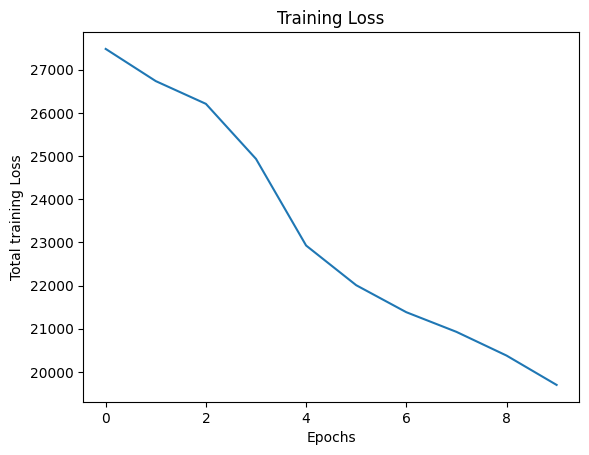

In [22]:
plt.figure()
plt.plot(total_loss, label='Training loss')                                                                          
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Total training Loss')            
plt.savefig(os.path.join(output_folder, 'train_loss.png'))

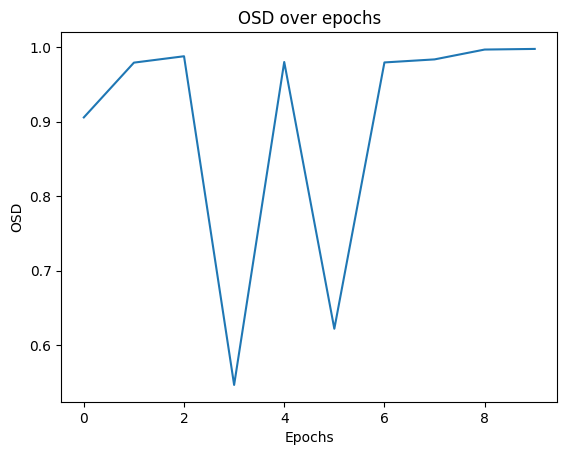

In [23]:
plt.figure()
plt.plot((osd_epochs), label='OSD')                                                                          
plt.title('OSD over epochs')
plt.xlabel('Epochs')
plt.ylabel('OSD')            
plt.savefig(os.path.join(output_folder, 'osd_over_epochs.png'))

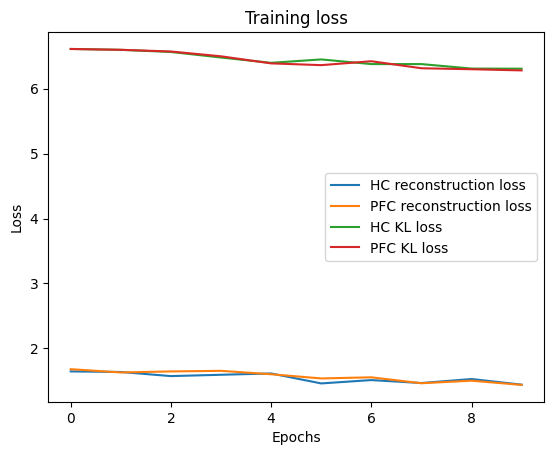

In [24]:
plt.figure()
names = ['reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        plt.plot(np.log(individual_loss[f'{dataset_abbrev[j]}_{set}']), label=f'{dataset_abbrev[j]} {names[i]}')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(output_folder, 'recon_kl_oneplot.png'))

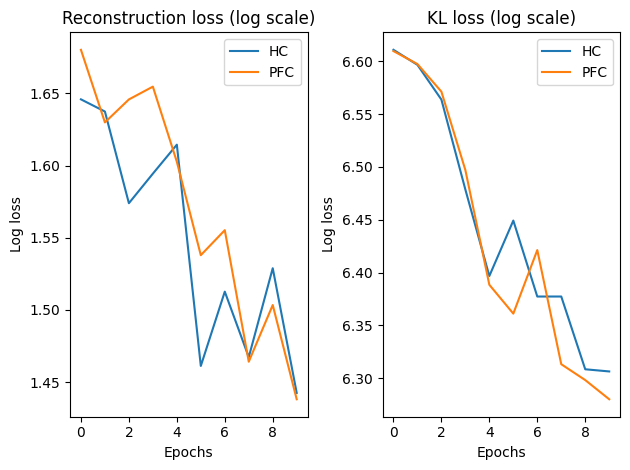

In [25]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(np.log(individual_loss[f'{dataset_abbrev[j]}_{set}']), label=f'{dataset_abbrev[j]}')
    ax[i].set_title(f'{names[i]} (log scale)')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs_log.png'))

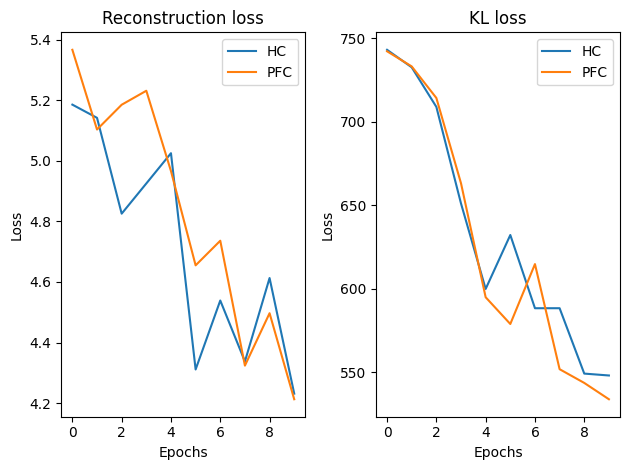

In [26]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(individual_loss[f'{dataset_abbrev[j]}_{set}'], label=f'{dataset_abbrev[j]}')
    ax[i].set_title(names[i])
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs.png'))

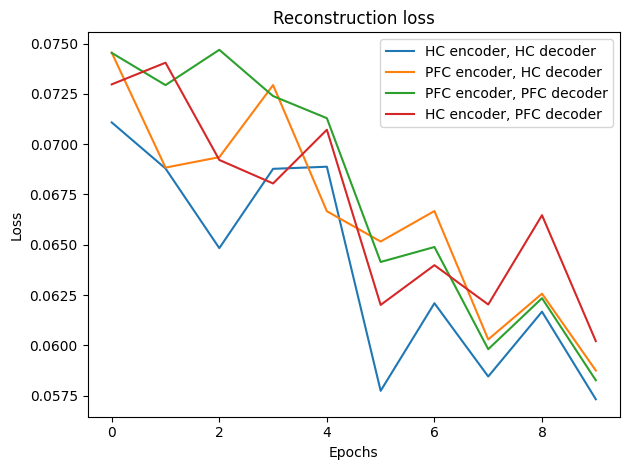

In [27]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot((recon_loss[f'{set}_{set}']), label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((recon_loss[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((recon_loss[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Reconstruction loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_recon_loss_graphs.png'))

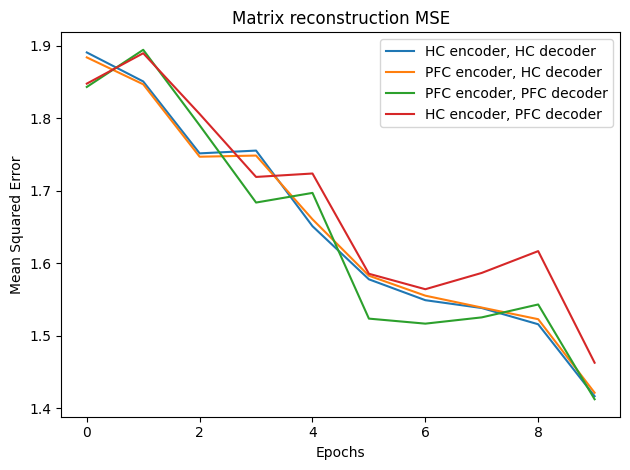

In [28]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_losses[f'{set}_{set}'], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_losses[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_losses[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Matrix reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_graphs.png'))

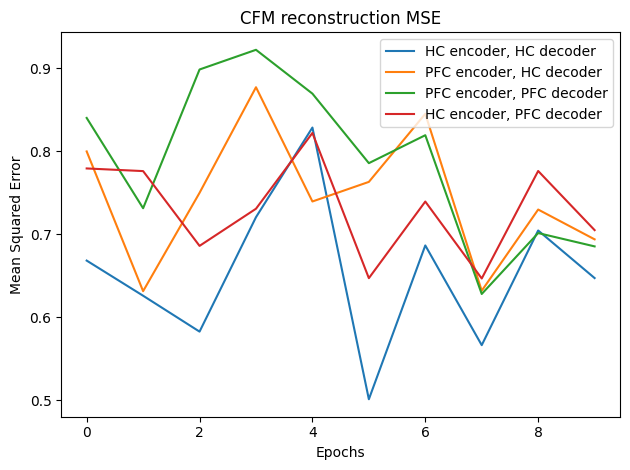

In [29]:
# Plotting each kind of reconstruction (cfm mse)
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_cfm_losses[f'{set}_{set}'], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_cfm_losses[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_cfm_losses[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('CFM reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_cfm_graphs.png'))

Visualizing the latent space

In [30]:
hues=['encoder', 'bin']

In [31]:
latent_space_1 = latent_space_1 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_2 = latent_space_2 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[1]}.csv'), index_col=False)

In [32]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [33]:
latent_space_1

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-0.821075,-0.087403,-3.109938,5.795674,8.792862,-1.101252,-0.457701,6.632320,2.094267,3.520009,3,1.243151,HC,124,1.277393
1,-2.015021,7.290148,10.122864,12.611817,6.056085,13.754765,0.023111,6.887195,5.687288,4.680623,3,1.243151,HC,124,1.277393
2,-3.404760,-0.954897,21.487099,-33.262486,6.173541,-16.193356,21.466196,-40.542350,-31.126102,3.215661,3,1.243151,HC,124,1.277393
3,-0.017482,37.088863,17.195797,-30.605204,-19.277733,-24.414824,-5.639875,28.350088,1.534736,4.688694,3,1.243151,HC,124,1.277393
4,-0.915980,1.362210,-7.053982,-2.387872,-0.867617,4.172623,-6.082729,9.032753,-2.985671,3.499162,3,1.243151,HC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-0.019059,-6.584329,-1.641216,12.932743,1.570496,2.814388,-2.674714,0.292090,-2.078413,0.061143,1,-0.215123,HC,28,-0.576731
9747,1.809203,19.766390,-7.826456,16.799470,17.568201,-5.427610,7.161220,-5.398912,4.406944,1.823812,1,-0.215123,HC,28,-0.576731
9748,-1.506841,6.954971,-2.884002,7.414052,-4.573384,-1.474484,-16.273537,6.664128,2.796980,1.208009,1,-0.215123,HC,28,-0.576731
9749,-0.170975,0.259702,-0.418950,-6.276844,3.947357,1.759576,0.601993,1.810352,14.620757,0.864686,1,-0.215123,HC,28,-0.576731


In [34]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)

In [35]:
prior_samples = pd.DataFrame(samples)
prior_samples['components'] = components

<Axes: xlabel='LV1', ylabel='Density'>

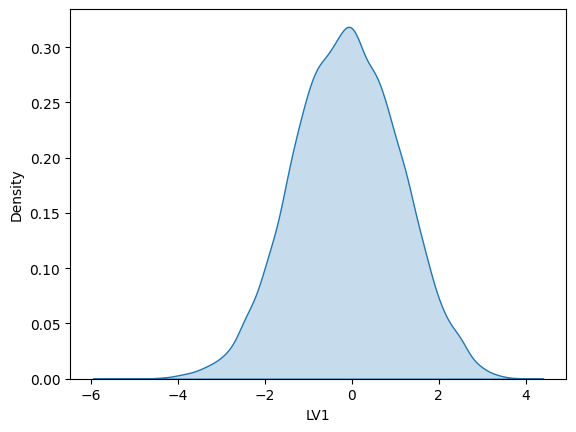

In [36]:
sns.kdeplot(data=latent_space_comb['LV1'], fill=True)

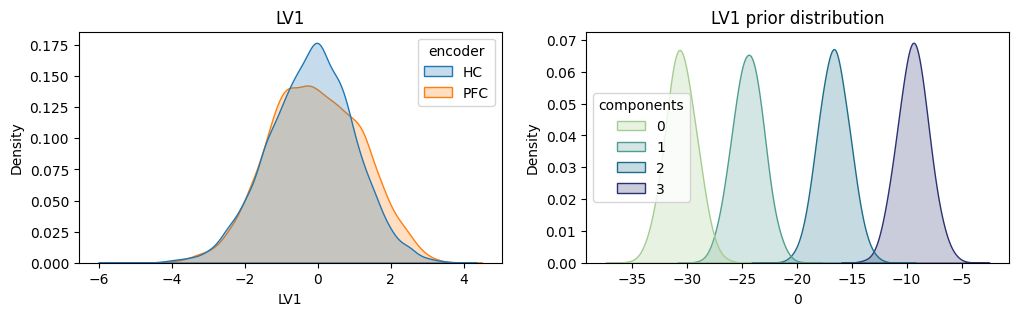

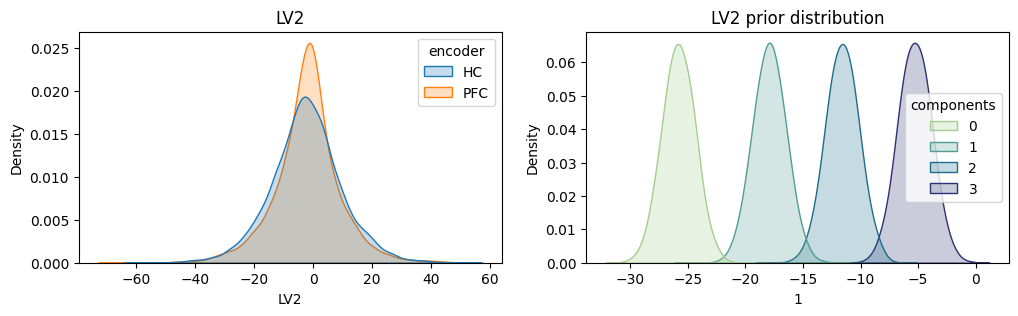

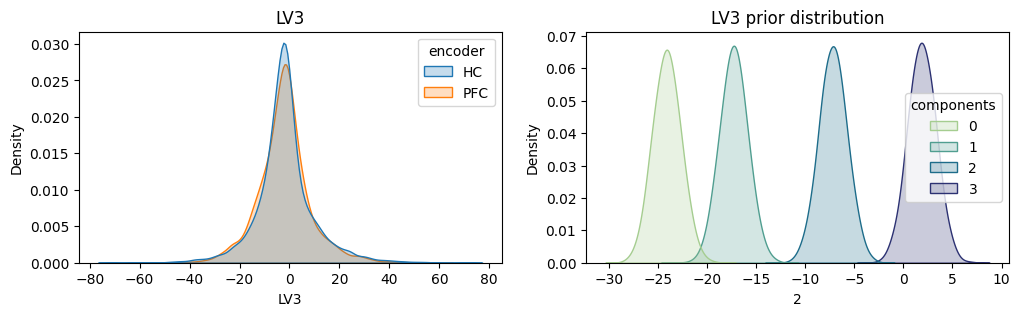

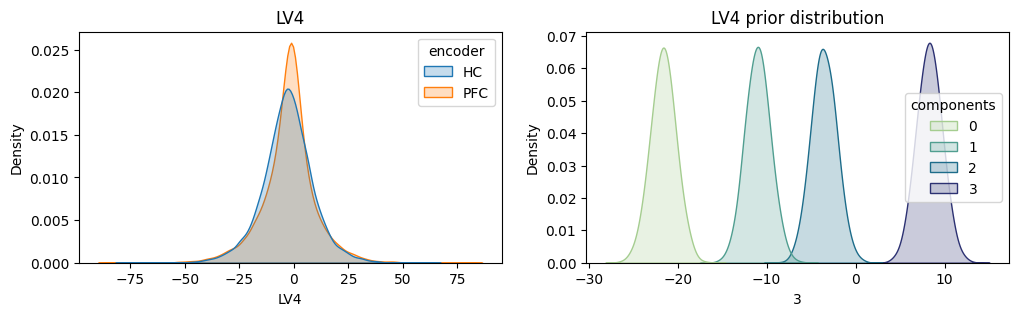

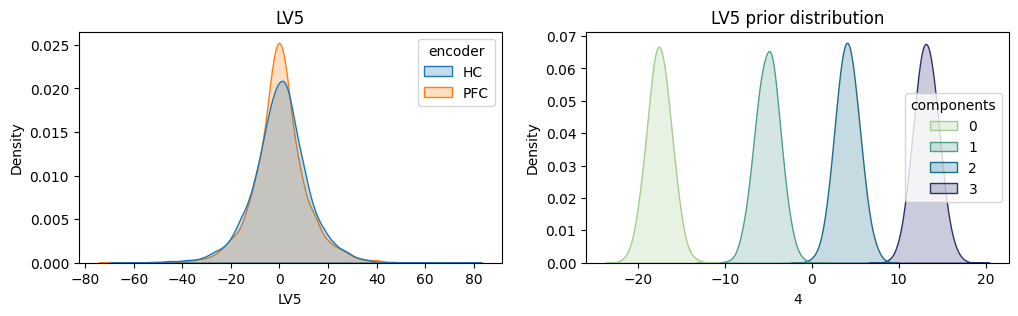

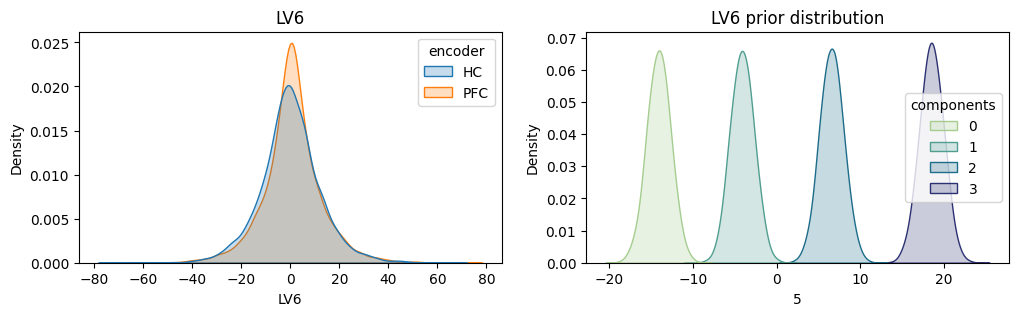

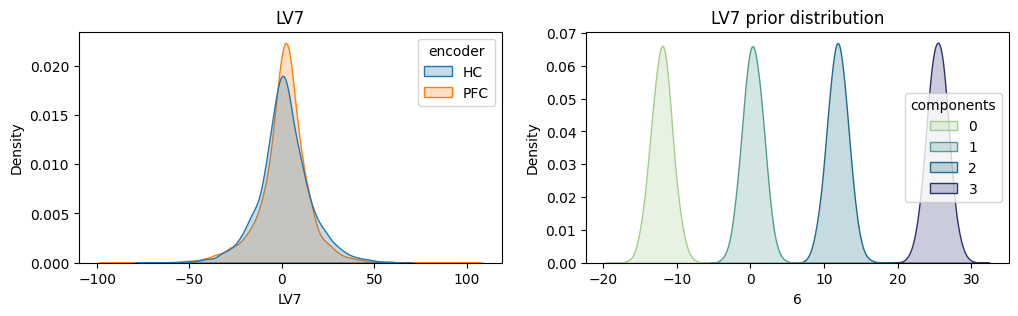

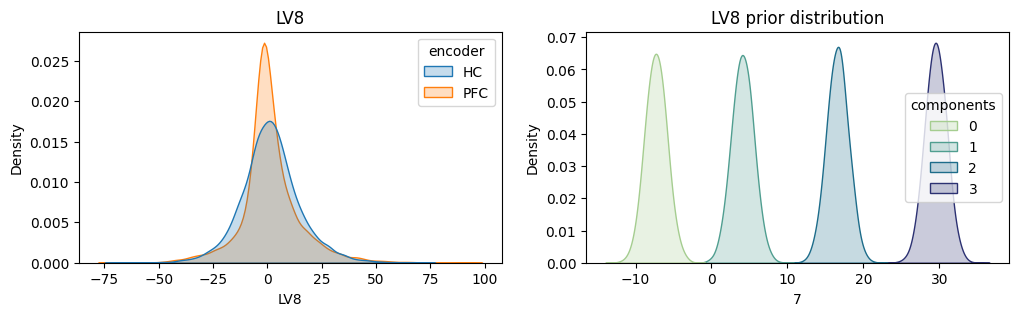

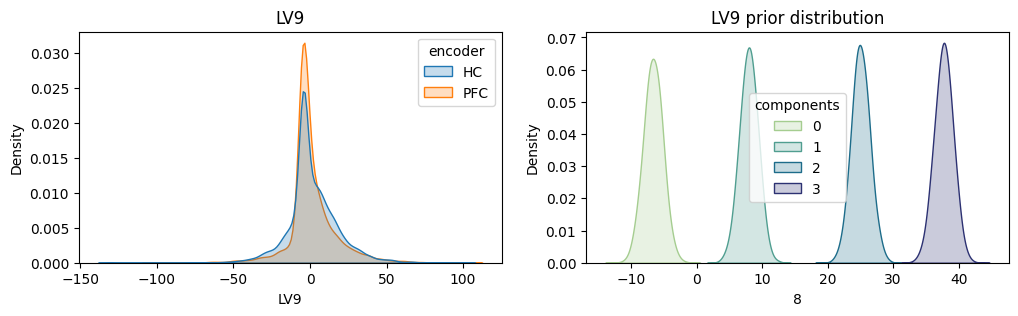

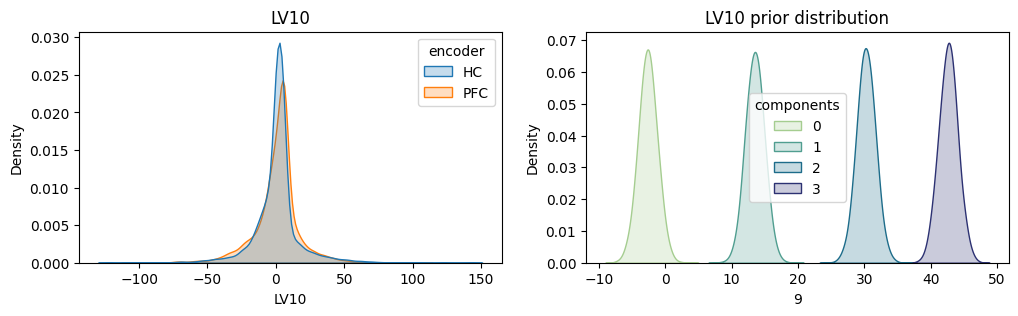

In [37]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=1, ax=ax[0])
    ax[0].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

/tmp/ipykernel_648206/3668661210.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_648206/3668661210.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


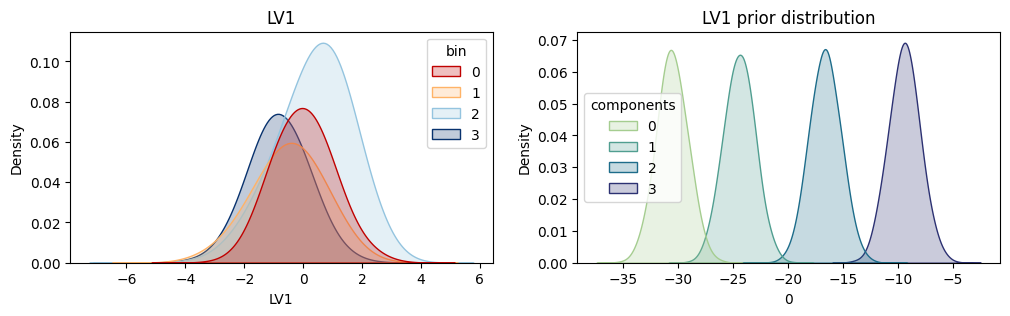

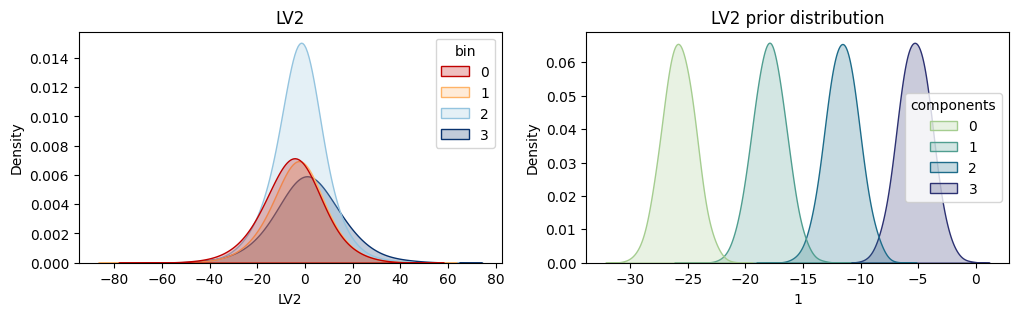

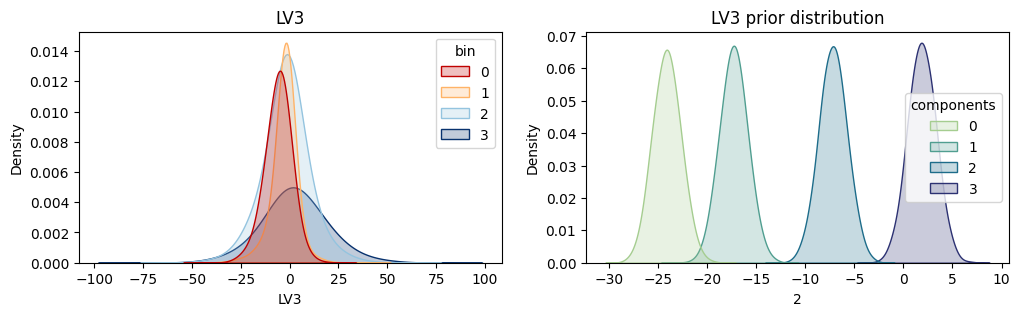

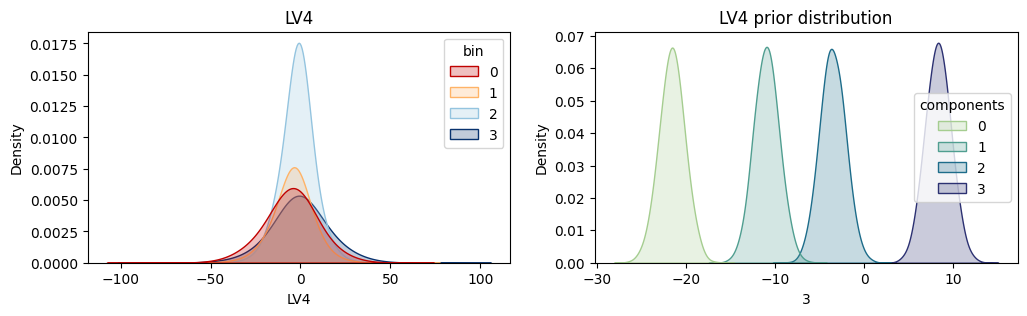

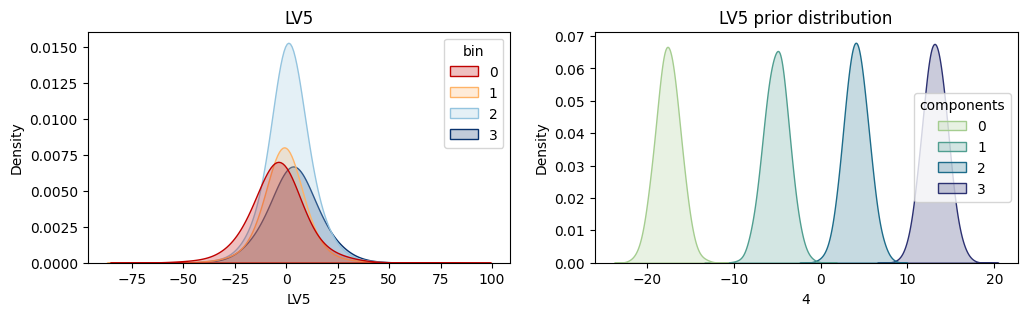

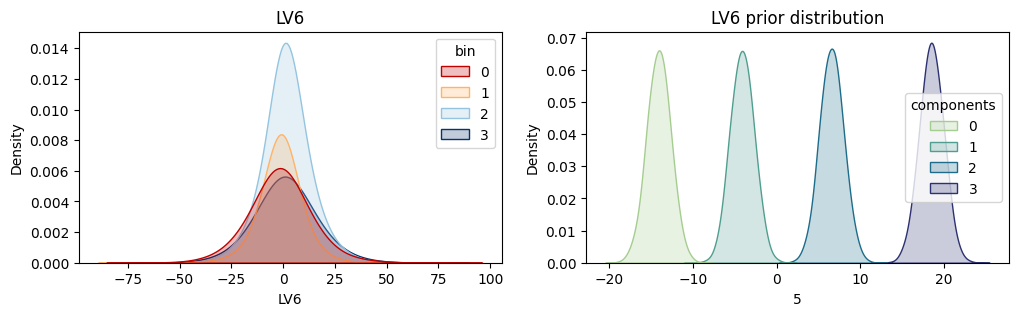

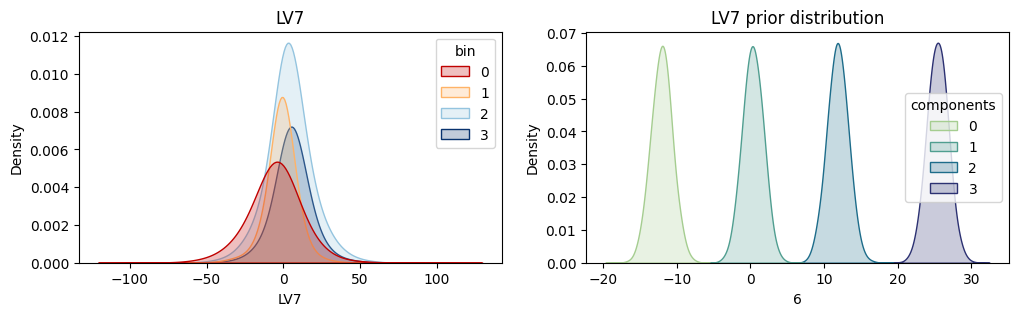

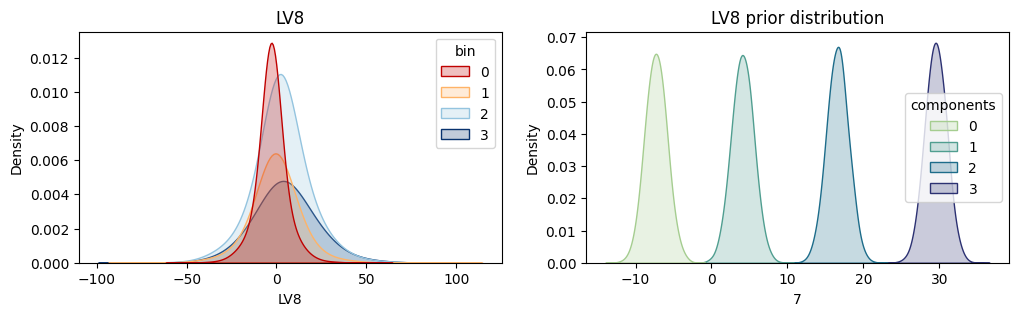

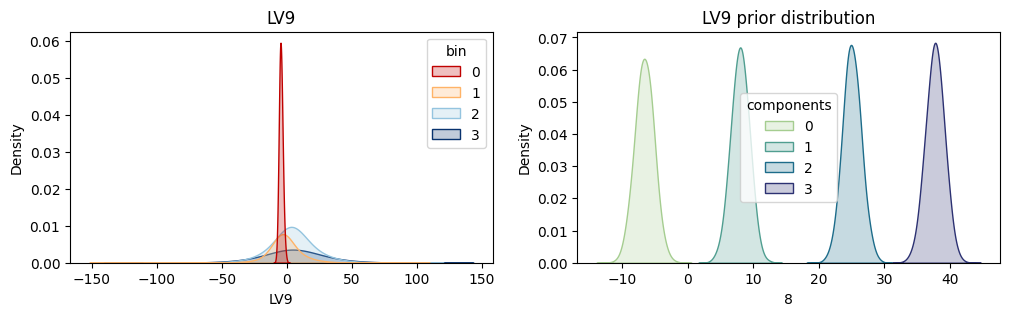

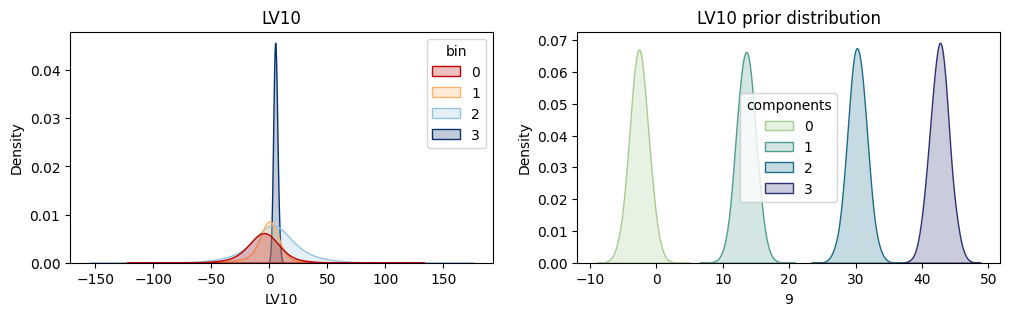

In [38]:
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'bin']], x=column, hue='bin', palette = custom_palette, fill=True, bw_adjust=3, ax=ax[0])
    ax[0].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

In [39]:
latent_space_comb['bin_enc'] = latent_space_comb['bin'].astype(str) + '_' +  latent_space_comb['encoder']

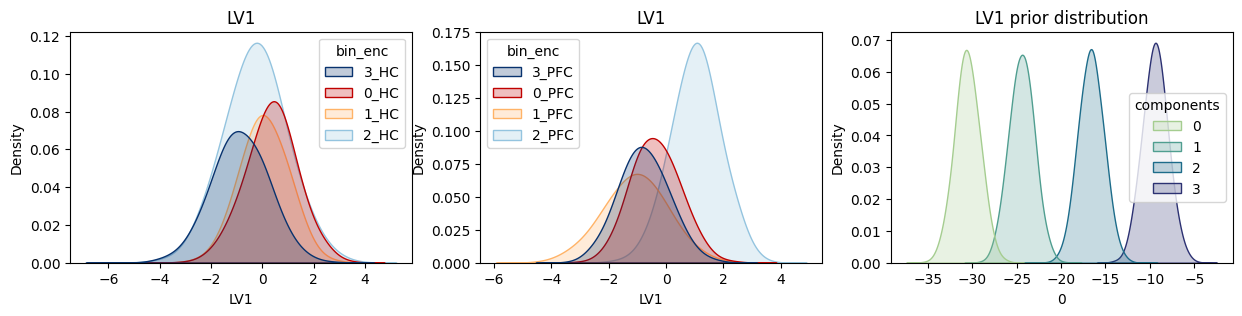

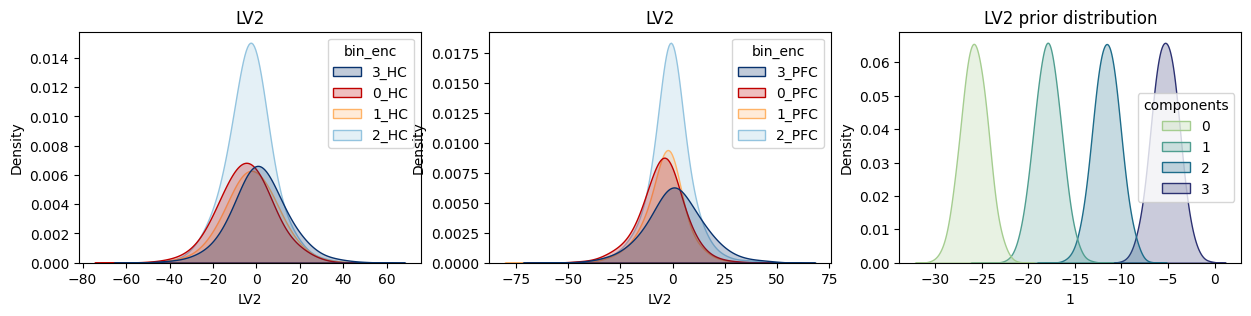

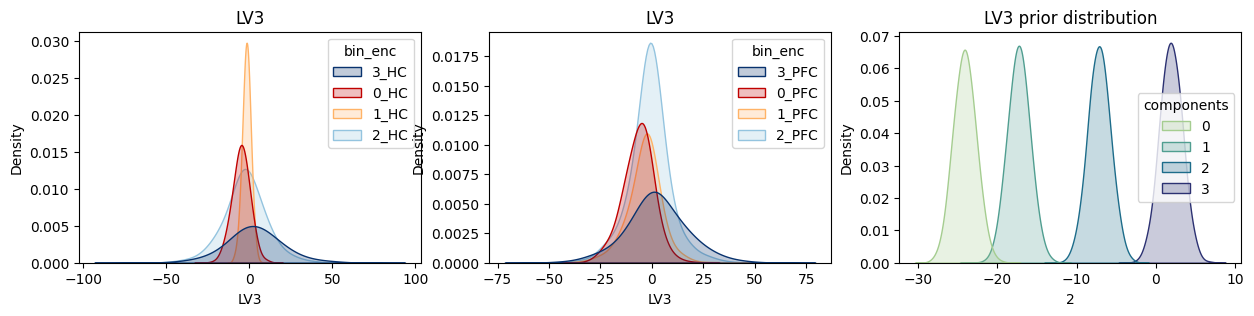

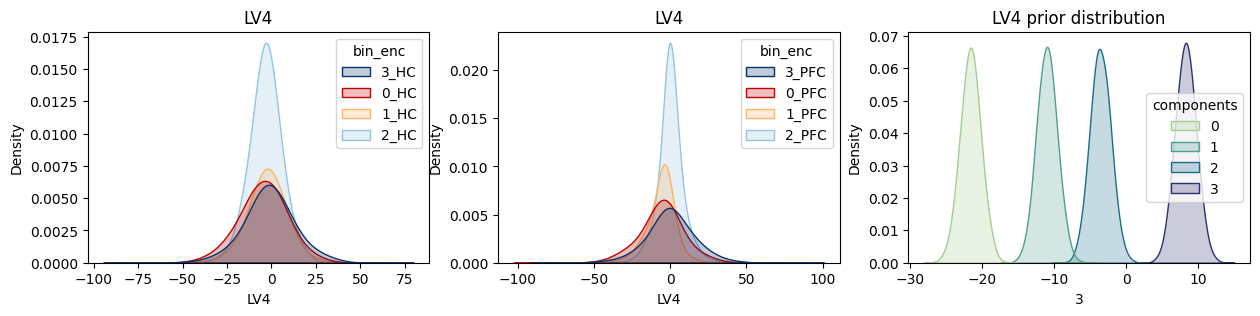

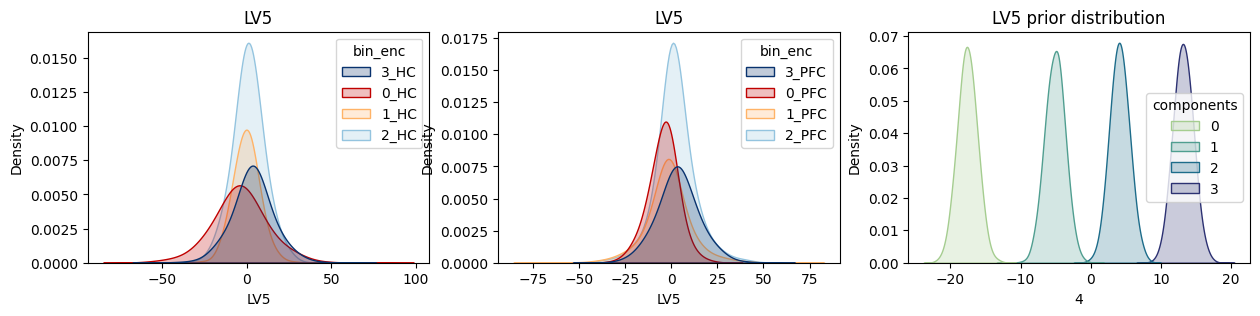

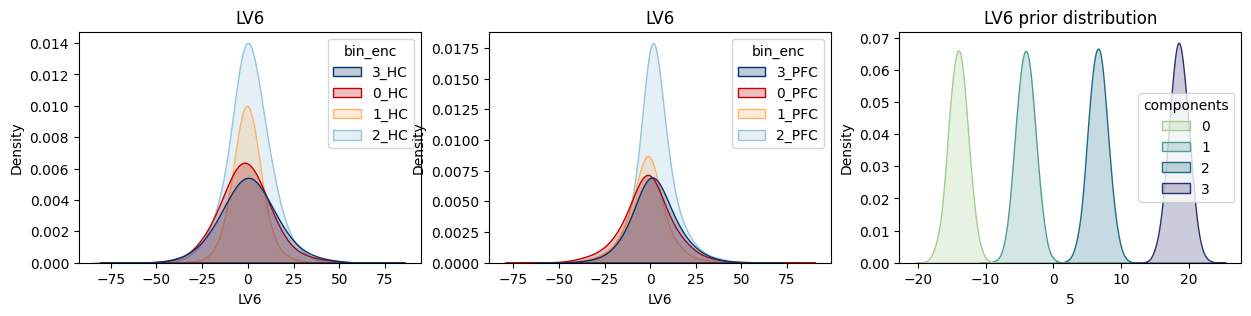

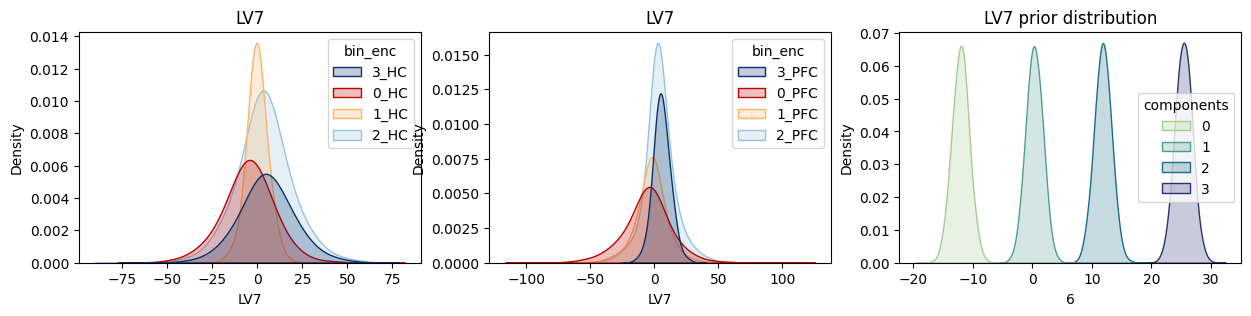

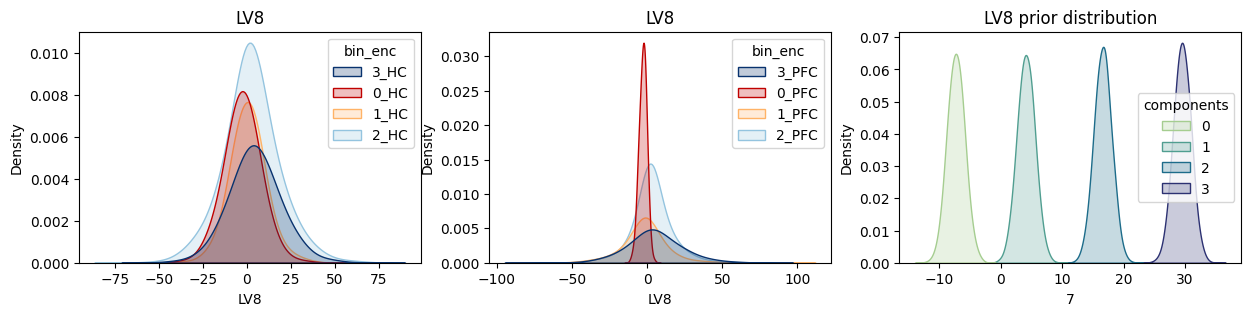

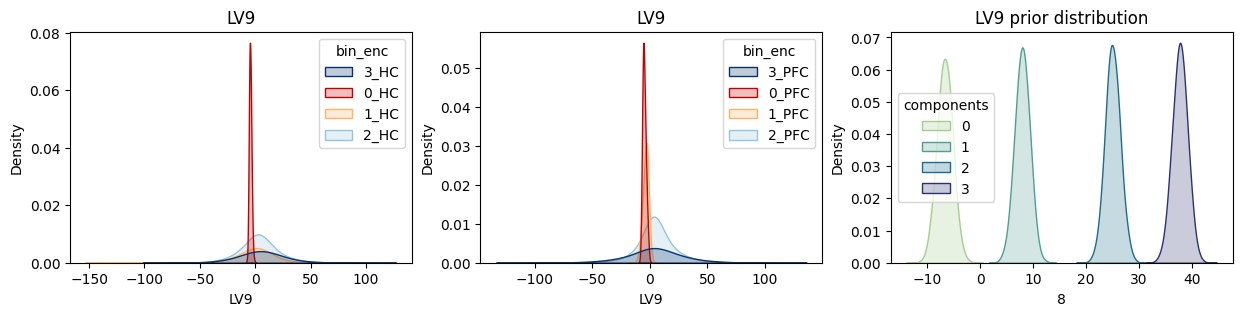

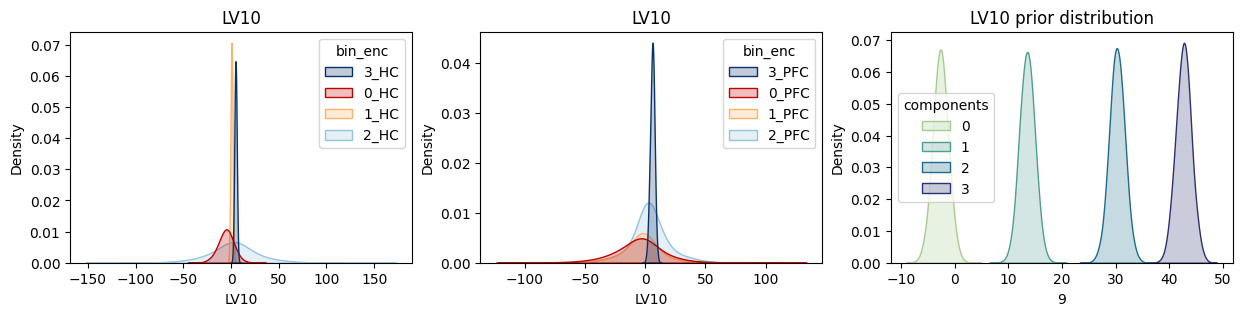

In [40]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    palette_HC = {f'0_{dataset_abbrev[0]}': cmap1(0.5), f'1_{dataset_abbrev[0]}': cmap1(0.85), f'2_{dataset_abbrev[0]}': cmap2(0.4), f'3_{dataset_abbrev[0]}': cmap2(0.99)}
    hc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[0])]
    sns.kdeplot(data=hc[[column, 'bin_enc']], x=column, hue='bin_enc', palette=palette_HC, fill=True, bw_adjust=2, ax=ax[0])
    ax[0].set_title(column)
    palette_HC2 = {f'0_{dataset_abbrev[1]}': cmap1(0.5), f'1_{dataset_abbrev[1]}': cmap1(0.85), f'2_{dataset_abbrev[1]}': cmap2(0.4), f'3_{dataset_abbrev[1]}': cmap2(0.99)}
    #palette_PFC = {'0_PFC': cmap1(0.5), '1_PFC': cmap1(0.85), '2_PFC': cmap2(0.4), '3_PFC': cmap2(0.99)}
    pfc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[1])]
    sns.kdeplot(data=pfc[[column, 'bin_enc']], x=column, hue='bin_enc', palette=palette_HC2, fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    ax[2].set_title(f'{column} prior distribution')

Plot the centers over epochs

In [41]:
from scipy.stats import norm

In [42]:
def plot_latent_progression(epoch_data_list, osd_epochs, gmm_centers, latent_dim, std=0.2, every_n_epochs=500, output_folder='.'):
    # epoch_data_list structure: [num_epochs][num_encoders][num_bins (of latent_dim size)]
    # gmm_centers structure: [num_epochs][num_encoders][num_bins][latent_dim]
    
    epochs_to_plot = range(0, len(epoch_data_list), every_n_epochs)
    num_plots = len(epochs_to_plot)
    
    fig, axes = plt.subplots(num_plots, 2, figsize=(14, num_plots * 1.5), sharex=True)
    if num_plots == 1: axes = np.expand_dims(axes, axis=0)
    
    # Calculate global limits based on the nested structure
    all_means = [bin_data[latent_dim] for epoch in epoch_data_list for encoder in epoch for bin_data in encoder]
    all_means = np.array(all_means)
    xmin, xmax = np.min(all_means) - 3*std, np.max(all_means) + 3*std
    x = np.linspace(xmin, xmax, 500)
    colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']

    for i, epoch_idx in enumerate(epochs_to_plot):
        osd = osd_epochs[epoch_idx]
        
        # Accessing nested lists for current epoch
        current_epoch_data = epoch_data_list[epoch_idx] # list of 2 encoders
        current_epoch_centers = gmm_centers # list of 2 encoders
        
        for enc_idx in range(2):
            ax = axes[i, enc_idx]
            encoder_bins = current_epoch_data[enc_idx]
            encoder_centers = current_epoch_centers[enc_idx]
            
            for bin_idx in range(len(encoder_bins)):
                # Access latent_dim from the bin vector
                m = encoder_bins[bin_idx][latent_dim]
                y = norm.pdf(x, m, std)
                
                ax.plot(x, y, color=colors[bin_idx % len(colors)], lw=1.5, alpha=0.8, label=f'Bin {bin_idx}')
                ax.fill_between(x, y, color=colors[bin_idx % len(colors)], alpha=0.3)
                
                # Plot GMM center as a red dot
                center_val = encoder_centers[bin_idx][latent_dim]
                ax.scatter(center_val, 0, color='red', zorder=5, s=30, marker='o')

            if i == 0:
                ax.set_title(f"Encoder {dataset_abbrev[enc_idx]}")
                ax.legend()
            if enc_idx == 0:
                ax.set_ylabel(f"Epoch {epoch_idx}\nOSD: {osd:.4f}", 
                              fontweight='bold', rotation=0, labelpad=50, va='center')
            
            ax.set_yticks([])
            ax.spines[['top', 'right', 'left']].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(f"Progression of Bin Separation (Dim {latent_dim})", y=0.98)
    
    save_path = os.path.join(output_folder, f'bins_dim_{latent_dim}_over_epochs.png')
    plt.savefig(save_path)
    plt.show()

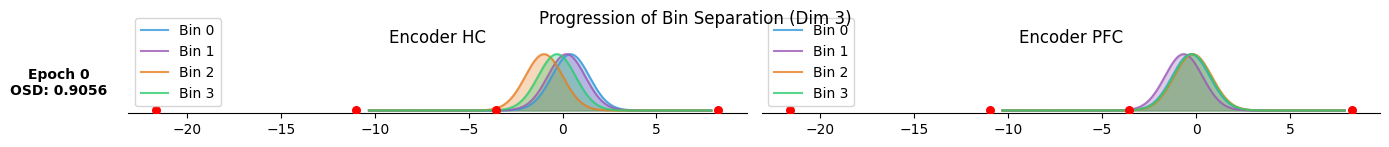

In [43]:
plot_latent_progression(bin_means_epochs, osd_epochs, gmm_centers, 3, 1, 1000, output_folder)

Plot phenotypic projection over time

In [44]:
# pheno_proj_1 = pd.read_csv(os.path.join(output_folder, f'phenotypic_projection_epoch{epochs}_vae{dataset_abbrev[0]}.csv'), index_col=False)
# pheno_proj_2 = pd.read_csv(os.path.join(output_folder, f'phenotypic_projection_epoch{epochs}_vae{dataset_abbrev[1]}.csv'), index_col=False)

In [45]:
pheno_proj = pd.read_csv(os.path.join(output_folder, f'phenotypic_projection_epoch5.csv'), index_col=False)
pheno_proj

,value,bin,encoder,overall_osd,encoder_osd
0,12.576746,3.0,HC,0.991128,0.965587
1,10.990349,3.0,HC,0.991128,0.965587
2,7.454008,3.0,HC,0.991128,0.965587
3,13.167077,3.0,HC,0.991128,0.965587
4,6.829867,3.0,HC,0.991128,0.965587
...,...,...,...,...,...
19497,-10.712616,1.0,PFC,0.991128,0.970539
19498,4.165175,1.0,PFC,0.991128,0.970539
19499,11.069287,1.0,PFC,0.991128,0.970539
19500,4.486317,1.0,PFC,0.991128,0.970539


In [46]:
def plot_pheno_proj_progression(output_folder, total_epochs):
    epochs_to_plot = np.linspace(1, total_epochs, 5).astype(int)
    fig, axes = plt.subplots(len(epochs_to_plot), 3, figsize=(20, len(epochs_to_plot)*1.5), sharex=True)

    cmap1 = cm.get_cmap('gist_heat')
    cmap2 = cm.get_cmap('Blues')
    custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
    
    for enc_idx, dataset in enumerate(dataset_abbrev):
        for i, epoch in enumerate(epochs_to_plot):
            pheno_proj = pd.read_csv(os.path.join(output_folder, f'phenotypic_projection_epoch{epoch}.csv'), index_col=False)
            pheno_proj = pheno_proj[pheno_proj['encoder']==dataset]
            osd = pheno_proj['encoder_osd'].mean()
            ax = axes[i, enc_idx]
            pheno_proj['bin'] = pheno_proj['bin'].astype(int)
            if i == 0 and enc_idx == 1:
                sns.kdeplot(data=pheno_proj, x='value', hue='bin',palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False, ax=ax)
            else: 
                sns.kdeplot(data=pheno_proj, x='value', hue='bin',palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False, ax=ax, legend=False)

            ax.set_xlabel('Phenotypic Projection')
            if i == 0:
                ax.set_title(f"Encoder {dataset_abbrev[enc_idx]}")
            ax.set_ylabel(f"Epoch {epoch}\nOSD: {osd:.4f}", 
                              fontweight='bold', rotation=0, labelpad=50, va='center')
    
    for i, epoch in enumerate(epochs_to_plot):
        pheno_proj = pd.read_csv(os.path.join(output_folder, f'phenotypic_projection_epoch{epoch}.csv'), index_col=False)
        osd = pheno_proj['overall_osd'].mean()
        ax = axes[i, 2]
        pheno_proj['bin'] = pheno_proj['bin'].astype(int)
        if i == 0 and enc_idx == 1:
            sns.kdeplot(data=pheno_proj, x='value', hue='bin',palette=custom_palette,fill=True,alpha=0.5,
                bw_adjust=3, common_norm=False, ax=ax)
        else: 
            sns.kdeplot(data=pheno_proj, x='value', hue='bin',palette=custom_palette,fill=True,alpha=0.5,
                bw_adjust=3, common_norm=False, ax=ax, legend=False)

        ax.set_xlabel('Phenotypic Projection')
        if i == 0:
            ax.set_title(f"All encoders combined")
        ax.set_ylabel(f"Epoch {epoch}\nOSD: {osd:.4f}", 
                            fontweight='bold', rotation=0, labelpad=50, va='center')
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.suptitle('Single encoder phenotypic projection over epochs', fontsize=15, fontweight='bold')

/tmp/ipykernel_648206/4003493263.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_648206/4003493263.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


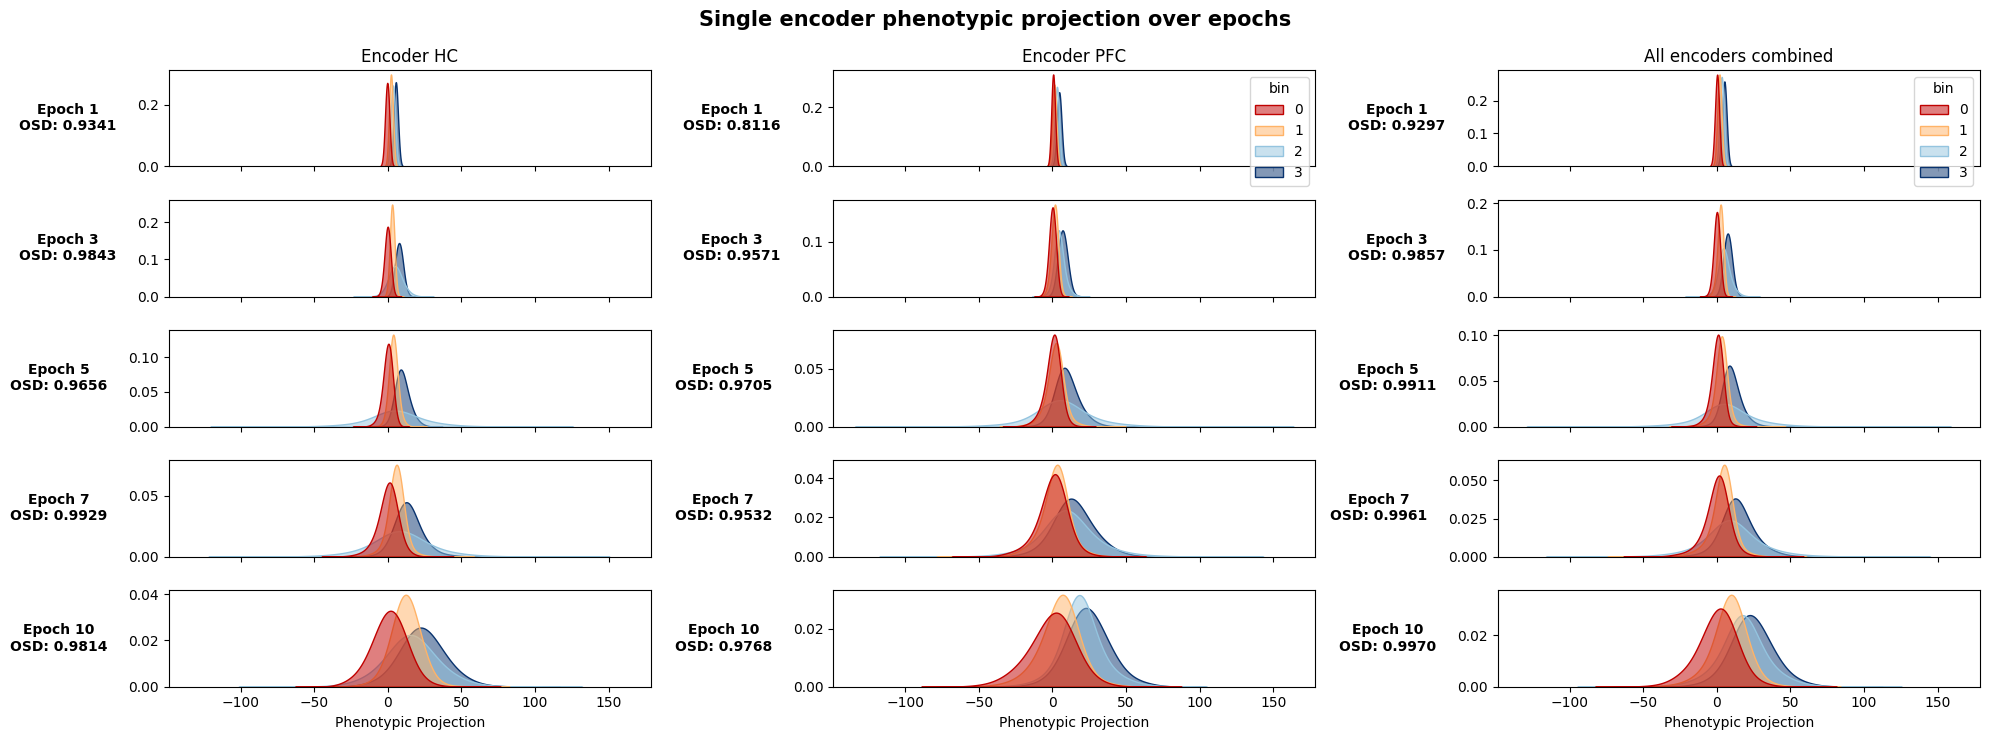

In [47]:
plot_pheno_proj_progression(output_folder, epochs)

In [48]:
latent_space_comb.iloc[:, :latent_dim]

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10
0,-0.821075,-0.087403,-3.109938,5.795674,8.792862,-1.101252,-0.457701,6.632320,2.094267,3.520009
1,-2.015021,7.290148,10.122864,12.611817,6.056085,13.754765,0.023111,6.887195,5.687288,4.680623
2,-3.404760,-0.954897,21.487099,-33.262486,6.173541,-16.193356,21.466196,-40.542350,-31.126102,3.215661
3,-0.017482,37.088863,17.195797,-30.605204,-19.277733,-24.414824,-5.639875,28.350088,1.534736,4.688694
4,-0.915980,1.362210,-7.053982,-2.387872,-0.867617,4.172623,-6.082729,9.032753,-2.985671,3.499162
...,...,...,...,...,...,...,...,...,...,...
19497,-2.515494,13.251504,4.805520,-17.093998,-32.628273,-6.763705,-6.908959,17.169147,-5.345507,13.984225
19498,-0.832129,-5.524442,-3.264878,4.978277,10.117514,-15.615665,2.765734,41.224860,-1.811866,-17.253070
19499,-1.665104,-2.782021,-6.862333,2.571630,-6.245571,-16.215122,-8.369420,-0.157456,-7.539075,-1.087704
19500,2.370732,-7.052962,-2.519963,-3.837553,-1.990274,1.223983,-3.256374,-3.378318,-0.076304,-4.904298


In [49]:
proj_points, osd = get_osd_from_latents_torch([torch.tensor(latent_space_comb.iloc[:, :latent_dim].values)], latent_space_comb['bin'], latent_space_comb['14-6-residual'], latent_space_comb['strain'], latent_dim)

In [50]:
proj_df = pd.DataFrame(proj_points, columns=['value', 'bin'])

/tmp/ipykernel_648206/1021264755.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_648206/1021264755.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


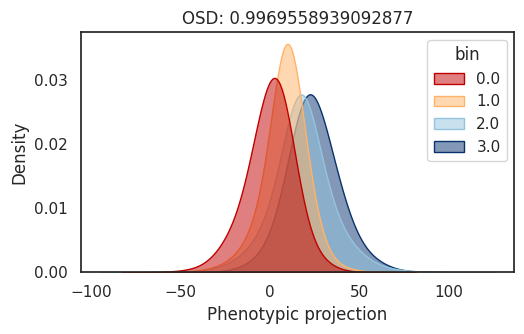

In [51]:
# plot phenotypic projection
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=proj_df, x='value',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
if not ax.legend_:
    plt.legend(title="bin",labels=proj_df["bin"].unique(),bbox_to_anchor=(1.05, 1))
plt.title("")
plt.xlabel('Phenotypic projection')
plt.title(f'OSD: {osd}')
plt.savefig(os.path.join(output_folder, 'phenotypic_projection.png'))
plt.tight_layout()
plt.show()

In [52]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [53]:
hues = ['encoder', 'bin']

In [54]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

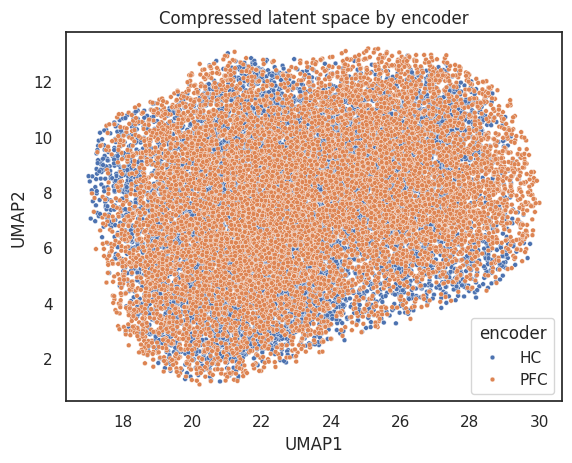

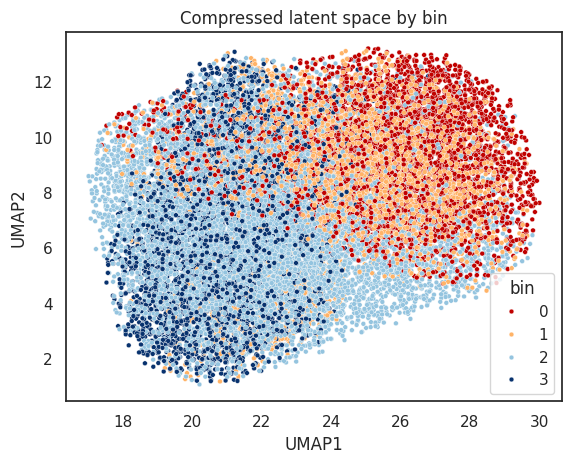

In [55]:
for hue in hues: 
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, palette=custom_palette, data=embedding_df, s=12)
    else: 
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [56]:
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]

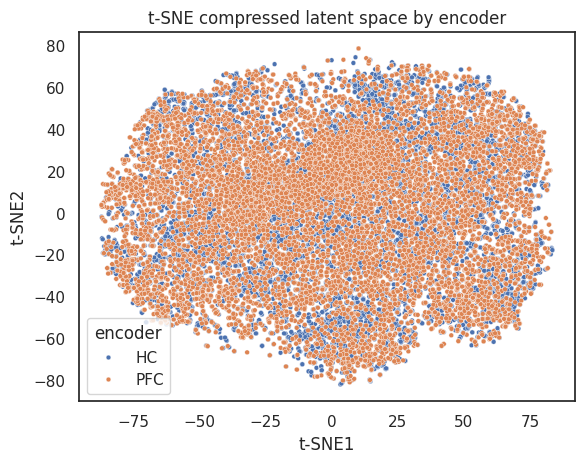

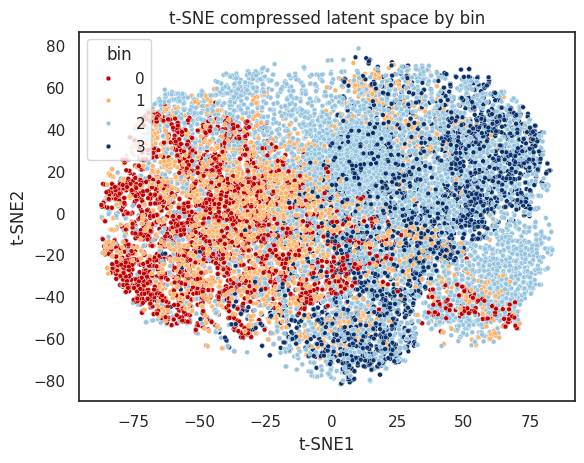

In [57]:
for hue in hues: 
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, palette=custom_palette, data=tsne_embedding_df, s=12)
    else:
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

Calculate and plot phenotypic projection

Latent space f-statistics

In [58]:
# latent_space_PFC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22/latent_variables_epoch5000_vaePFC.csv')
# latent_space_PFC

In [59]:
# latent_space_HC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22/latent_variables_epoch5000_vaeHC.csv')
# latent_space_HC

In [60]:
# latent_space_comb = pd.concat([latent_space_PFC, latent_space_HC])
# latent_space_comb = latent_space_comb.reset_index()
# latent_space_comb = latent_space_comb.iloc[:, 1:]
# latent_dim=10
# dataset_abbrev = ['HC', 'PFC']

In [61]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

le = LabelEncoder()
y = le.fit_transform(latent_space_comb['encoder'])
y

array([0, 0, 0, ..., 1, 1, 1])

In [62]:
f_values, p_values = f_classif(latent_space_comb.iloc[:, :latent_dim], y)
latents_ordered = np.argsort(f_values)[::-1]
latents_ordered

array([0, 5, 3, 2, 1, 6, 8, 7, 4, 9])

In [63]:
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 
print('Latent feature variance correlations with encoder classification')
for col in latents_ordered:
    print(f'{latent_cols[col]}: {f_values[col], p_values[col]}')

Latent feature variance correlations with encoder classification
LV1: (45.53685495563747, 1.540006838313015e-11)
LV6: (17.936868614258657, 2.2940111733420663e-05)
LV4: (12.36419928793747, 0.0004386391009544401)
LV3: (6.067745779247085, 0.013775827898572238)
LV2: (4.778317447351692, 0.028832116764188665)
LV7: (2.8814312436568446, 0.08962230137681998)
LV9: (2.481453521447887, 0.11521197288841985)
LV8: (1.059059125060111, 0.3034426391095198)
LV5: (0.1603867359258927, 0.6888050951824665)
LV10: (0.06089165404895976, 0.8050947526980826)


In [64]:
fclass_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'f_values': f_values,
    'p_values': p_values
}).sort_values(by='f_values', ascending=False)
fclass_importance_df

,Latent variable,f_values,p_values
0,LV1,45.536855,1.540007e-11
5,LV6,17.936869,2.294011e-05
3,LV4,12.364199,4.386391e-04
2,LV3,6.067746,1.377583e-02
1,LV2,4.778317,2.883212e-02
6,LV7,2.881431,8.962230e-02
8,LV9,2.481454,1.152120e-01
7,LV8,1.059059,3.034426e-01
4,LV5,0.160387,6.888051e-01
9,LV10,0.060892,8.050948e-01


SVM to predict features relevant to encoder classification

In [65]:
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

In [66]:
rbf_model = SVC(kernel='rbf')
rbf_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [67]:
results = permutation_importance(rbf_model, latent_space_comb.iloc[:, :latent_dim], y, n_repeats=10, random_state=random_seed)

In [68]:
rbf_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': results.importances_mean, 
    'Abs_weight': abs(results.importances_mean)
}).sort_values(by='Abs_weight', ascending=False)
rbf_importance_df
rbf_importance_df.to_csv(os.path.join(output_folder, 'rbf_svm_weights.csv'))

In [69]:
for i in results.importances_mean.argsort()[::-1]:
    print(f"{latent_cols[i]}: {results.importances_mean[i]:.4f}")

LV9: 0.0662
LV10: 0.0619
LV8: 0.0423
LV7: 0.0375
LV2: 0.0331
LV4: 0.0322
LV5: 0.0302
LV3: 0.0264
LV6: 0.0258
LV1: 0.0141


In [70]:
# with linear kernel 
linear_model = SVC(kernel='linear')
linear_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
weights = linear_model.coef_[0]
importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': weights, 
    'Abs_weight': abs(weights)
}).sort_values(by='Abs_weight', ascending=False)
importance_df.to_csv(os.path.join(output_folder, 'linear_svm_weights.csv'))

Generate correlation plots between latent variables

In [72]:
from itertools import product

In [73]:
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual,bin_enc
0,-0.821075,-0.087403,-3.109938,5.795674,8.792862,-1.101252,-0.457701,6.632320,2.094267,3.520009,3,1.243151,HC,124,1.277393,3_HC
1,-2.015021,7.290148,10.122864,12.611817,6.056085,13.754765,0.023111,6.887195,5.687288,4.680623,3,1.243151,HC,124,1.277393,3_HC
2,-3.404760,-0.954897,21.487099,-33.262486,6.173541,-16.193356,21.466196,-40.542350,-31.126102,3.215661,3,1.243151,HC,124,1.277393,3_HC
3,-0.017482,37.088863,17.195797,-30.605204,-19.277733,-24.414824,-5.639875,28.350088,1.534736,4.688694,3,1.243151,HC,124,1.277393,3_HC
4,-0.915980,1.362210,-7.053982,-2.387872,-0.867617,4.172623,-6.082729,9.032753,-2.985671,3.499162,3,1.243151,HC,124,1.277393,3_HC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,-2.515494,13.251504,4.805520,-17.093998,-32.628273,-6.763705,-6.908959,17.169147,-5.345507,13.984225,1,-0.215123,PFC,28,-0.576731,1_PFC
19498,-0.832129,-5.524442,-3.264878,4.978277,10.117514,-15.615665,2.765734,41.224860,-1.811866,-17.253070,1,-0.215123,PFC,28,-0.576731,1_PFC
19499,-1.665104,-2.782021,-6.862333,2.571630,-6.245571,-16.215122,-8.369420,-0.157456,-7.539075,-1.087704,1,-0.215123,PFC,28,-0.576731,1_PFC
19500,2.370732,-7.052962,-2.519963,-3.837553,-1.990274,1.223983,-3.256374,-3.378318,-0.076304,-4.904298,1,-0.215123,PFC,28,-0.576731,1_PFC


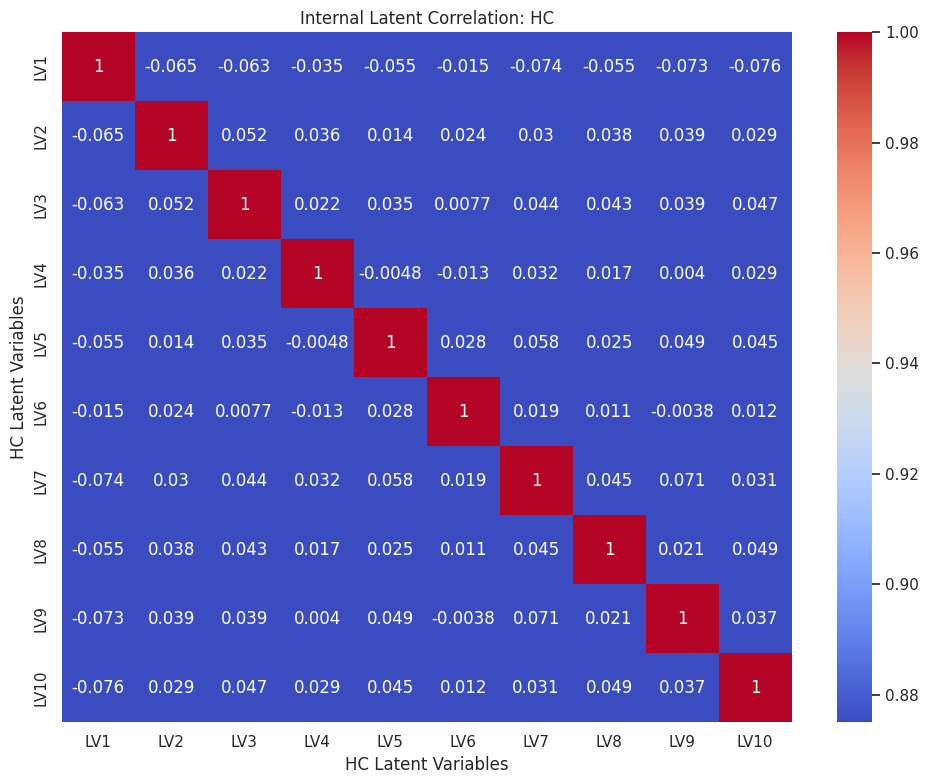

<Figure size 640x480 with 0 Axes>

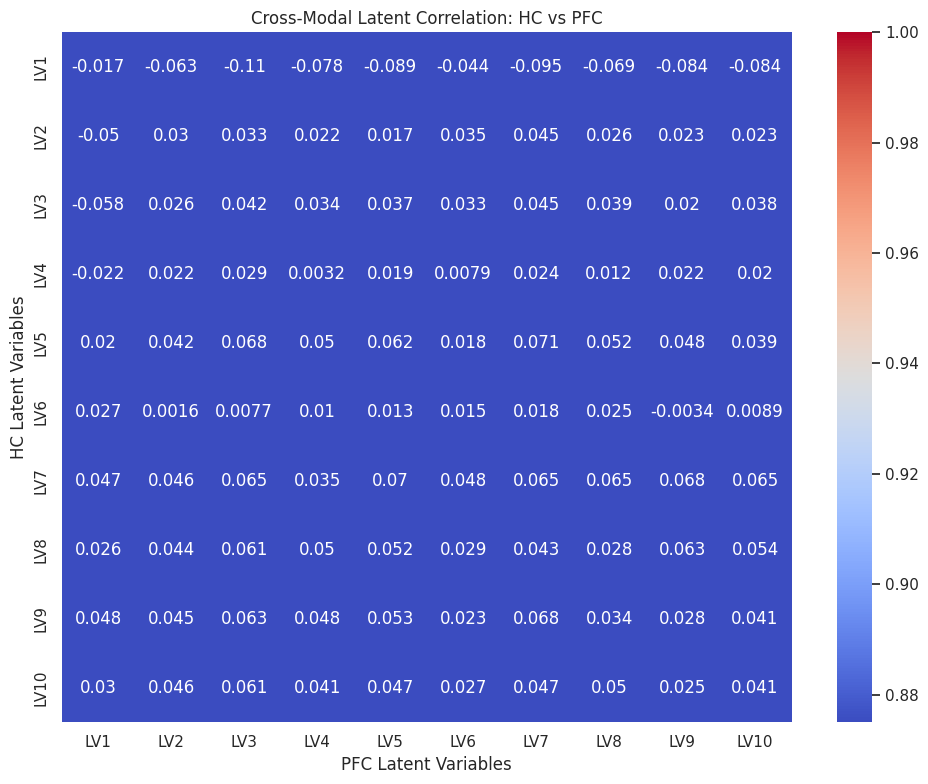

<Figure size 640x480 with 0 Axes>

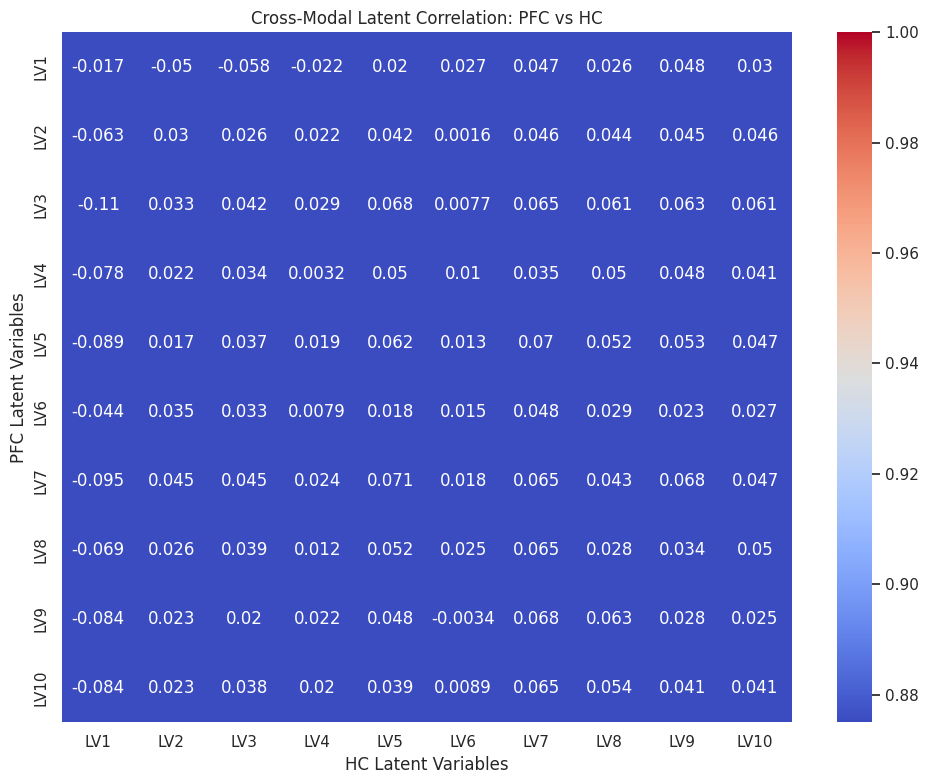

<Figure size 640x480 with 0 Axes>

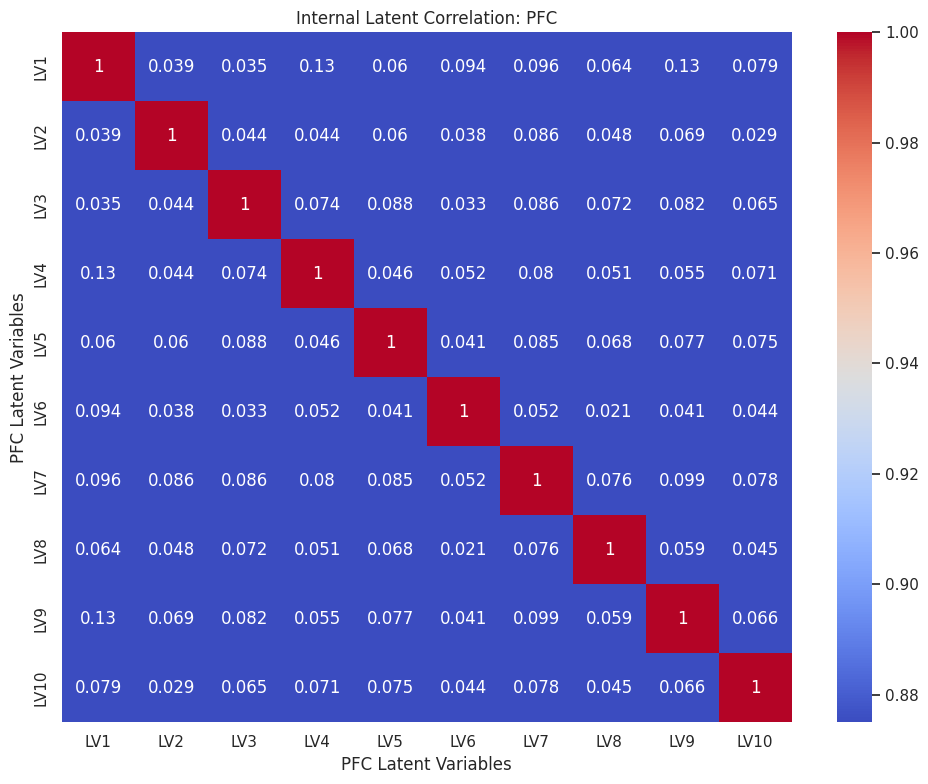

<Figure size 640x480 with 0 Axes>

In [74]:
unique_encoders = latent_space_comb['encoder'].unique()
encoder_pairs = list(product(unique_encoders, repeat=2))
for enc1, enc2 in encoder_pairs:
    z1 = latent_space_comb[latent_space_comb['encoder'] == enc1].iloc[:, :latent_dim]
    z2 = latent_space_comb[latent_space_comb['encoder'] == enc2].iloc[:, :latent_dim]
    
    if len(z1) != len(z2):
        print(f"Skipping {enc1} vs {enc2} due to row count mismatch.")
        continue

    stacked = np.hstack((z1, z2))
    full_corr = np.corrcoef(stacked.T)
    cross_corr = full_corr[:latent_dim, latent_dim:]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cross_corr, 
        annot=True, 
        cmap='coolwarm', 
        xticklabels=latent_cols,
        yticklabels=latent_cols, 
        vmin=0.875, 
        vmax=1
    )
    
    plt.xlabel(f"{enc2} Latent Variables", fontsize=12)
    plt.ylabel(f"{enc1} Latent Variables", fontsize=12)
    if enc1 == enc2:
        plt.title(f"Internal Latent Correlation: {enc1}")
    else:
        plt.title(f"Cross-Modal Latent Correlation: {enc1} vs {enc2}")
    plt.tight_layout()
    plt.show()
    if enc1 == enc2:
        plt.savefig(os.path.join(output_folder, f"InternalLatentCorrelation:{enc1}.png"))
    else:
        plt.savefig(os.path.join(output_folder, f"Cross-ModalLatentCorrelation:{enc1}vs{enc2}.png"))